# Static–dynamic temporal-generalization decoding

This notebook decodes **stimulus identity** from population activity. Each matrix trains a configurable classifier at one time point (rows) and evaluates it at every test time point (columns). It computes all four requested directions:

- static → static (stratified cross-validation)
- dynamic → dynamic (stratified cross-validation)
- static → dynamic (independent-session cross-decoding), and
- dynamic → static (independent-session cross-decoding).

The dynamic raster is read starting at 2,000 ms and both conditions are binned directly from 1,000 Hz to 100 Hz. Scaling, class balancing, and optional alpha selection are learned from training data only. Balanced accuracy gives every stimulus equal weight despite unequal repetition counts.


In [1]:
import os
import sys
from dataclasses import dataclass
from pathlib import Path

import matplotlib.pyplot as plt
from matplotlib.colors import TwoSlopeNorm
import numpy as np
import yaml


# Locate the project whether Jupyter starts in the repository or scripts/.
PROJECT_ROOT = Path.cwd().resolve()
while not (PROJECT_ROOT / "config.yaml").is_file():
    if PROJECT_ROOT.parent == PROJECT_ROOT:
        raise FileNotFoundError("Could not find config.yaml above the notebook.")
    # end if filesystem root
    PROJECT_ROOT = PROJECT_ROOT.parent
# end while config.yaml is missing

ENV = os.getenv("MY_ENV", "tiziano_mac_mini")
with open(PROJECT_ROOT / "config.yaml", "r") as file:
    config = yaml.safe_load(file)
# end with open
paths = config[ENV]["paths"]
for source_path in (paths["src_path"], paths["useful_stuff_path"]):
    if source_path not in sys.path:
        sys.path.append(source_path)
    # end if source_path
# end for source_path

from project_specific_utils import (
    load_binned_raster, load_raster_presentation_names,
)
from project_specific_utils.temporal_decoding import (
    cross_validated_temporal_generalization,
    select_shared_decoding_presentations,
    temporal_generalization,
)


In [2]:
@dataclass
class Cfg:
    # The red sessions are the lighter local defaults; swap to baby1 if needed.
    static_exp_name: str = "baby1_260718to27" # "red_20260726to27" # 
    dynamic_exp_name: str = "baby1_260716to24" #"red_20260720to24" # 

    # Options: last_frame, 2000ms, or 2250ms.
    static_response: str = "last_frame"

    # Inclusive one-based MATLAB channels; None retains all channels.
    good_channels: tuple[int, int] | None =  (84, 186) # None # 

    source_fs: float = 1000
    target_fs: float = 100
    static_start_ms: float = 0
    static_end_ms: float | None = 1000
    dynamic_start_ms: float = 2000
    dynamic_end_ms: float | None = None

    # Options: ridge, logistic_regression, linear_svm, or rbf_svm.
    # rbf_svm is nonlinear and substantially slower than the other choices.
    classifier_name: str = "logistic_regression"

    # Multiple values enable inner CV at every decoder-training time.
    # For logistic/SVM models, C = 1 / alpha.
    alpha_values: tuple[float, ...] = (0.01, 0.1, 1.0, 10.0, 100.0)
    alpha_cv_splits: int = 3
    classifier_max_iter: int = 10000
    rbf_gamma: str | float = "scale"
    n_splits: int = 5
    random_seed: int = 0

    figure_dpi: int = 120
    save_results: bool = True
    results_dir: Path | None = None


cfg = Cfg()
plt.rcParams["figure.dpi"] = cfg.figure_dpi
cfg


Cfg(static_exp_name='baby1_260718to27', dynamic_exp_name='baby1_260716to24', static_response='last_frame', good_channels=(84, 186), source_fs=1000, target_fs=100, static_start_ms=0, static_end_ms=1000, dynamic_start_ms=2000, dynamic_end_ms=None, classifier_name='logistic_regression', alpha_values=(0.01, 0.1, 1.0, 10.0, 100.0), alpha_cv_splits=3, classifier_max_iter=10000, rbf_gamma='scale', n_splits=5, random_seed=0, figure_dpi=120, save_results=True, results_dir=None)

## Select matched repeated presentations

Presentation names are inspected before raster loading. This allows the loader to read only the requested static control, the shared stimulus classes, and the dynamic interval beginning at 2,000 ms.


In [3]:
data_dir = Path(paths["data_path"]) / "data"
static_path = data_dir / f"{cfg.static_exp_name}_raster_img.mat"
dynamic_path = data_dir / f"{cfg.dynamic_exp_name}_raster_vid.mat"
for raster_path in (static_path, dynamic_path):
    if not raster_path.is_file():
        raise FileNotFoundError(raster_path)
    # end if missing raster
# end for raster_path

static_names = load_raster_presentation_names(static_path)
dynamic_names = load_raster_presentation_names(dynamic_path)
(
    static_indices, dynamic_indices, static_labels, dynamic_labels,
    shared_stimuli,
) = select_shared_decoding_presentations(
    static_names, dynamic_names, cfg.static_response,
)

# Convert the optional one-based MATLAB range into a Python slice.
if cfg.good_channels is None:
    channel_slice = slice(None)
else:
    first_channel, last_channel = cfg.good_channels
    if first_channel < 1 or last_channel < first_channel:
        raise ValueError("good_channels must be an increasing one-based range.")
    # end if invalid good_channels
    channel_slice = slice(first_channel - 1, last_channel)
# end if good_channels

# Convert requested millisecond windows to source-sample boundaries.
static_start_sample = int(round(cfg.static_start_ms * cfg.source_fs / 1000))
dynamic_start_sample = int(round(cfg.dynamic_start_ms * cfg.source_fs / 1000))
static_end_sample = (
    None if cfg.static_end_ms is None
    else int(round(cfg.static_end_ms * cfg.source_fs / 1000))
)
dynamic_end_sample = (
    None if cfg.dynamic_end_ms is None
    else int(round(cfg.dynamic_end_ms * cfg.source_fs / 1000))
)

print(f"Shared stimulus classes: {len(shared_stimuli)}")
print(f"Static presentations: {len(static_indices)}")
print(f"Dynamic presentations: {len(dynamic_indices)}")


Shared stimulus classes: 100
Static presentations: 3437
Dynamic presentations: 2733


In [4]:
# Bin during HDF5 loading, avoiding full 1,000 Hz arrays in memory.
static_rasters, _ = load_binned_raster(
    static_path, source_fs=cfg.source_fs, target_fs=cfg.target_fs,
    channel_slice=channel_slice, start_sample=static_start_sample,
    end_sample=static_end_sample, presentation_indices=static_indices,
)
dynamic_rasters, _ = load_binned_raster(
    dynamic_path, source_fs=cfg.source_fs, target_fs=cfg.target_fs,
    channel_slice=channel_slice, start_sample=dynamic_start_sample,
    end_sample=dynamic_end_sample, presentation_indices=dynamic_indices,
)

if static_rasters.shape[0] != dynamic_rasters.shape[0]:
    raise ValueError("Static and dynamic sessions retained different channels.")
# end if channel counts differ

# Label each bin by its left edge, matching the project's existing convention.
bin_width_ms = 1000 / cfg.target_fs
static_times_ms = cfg.static_start_ms + np.arange(static_rasters.shape[1]) * bin_width_ms
dynamic_times_ms = cfg.dynamic_start_ms + np.arange(dynamic_rasters.shape[1]) * bin_width_ms
if cfg.good_channels is None:
    channel_numbers = np.arange(1, static_rasters.shape[0] + 1)
else:
    channel_numbers = np.arange(cfg.good_channels[0], cfg.good_channels[1] + 1)
# end if good_channels

static_counts = np.bincount(static_labels, minlength=len(shared_stimuli))
dynamic_counts = np.bincount(dynamic_labels, minlength=len(shared_stimuli))
chance_accuracy = 1 / len(shared_stimuli)

print(f"Static raster: {static_rasters.shape}")
print(f"Dynamic raster: {dynamic_rasters.shape}")
print(f"Static repetition range: {static_counts.min()}-{static_counts.max()}")
print(f"Dynamic repetition range: {dynamic_counts.min()}-{dynamic_counts.max()}")
print(f"Chance balanced accuracy: {chance_accuracy:.3f}")


Static raster: (103, 100, 3437)
Dynamic raster: (103, 150, 2733)
Static repetition range: 32-36
Dynamic repetition range: 15-44
Chance balanced accuracy: 0.010


## Decode within and across conditions

Within-condition matrices average stratified outer folds, so no presentation is used for both fitting and testing within a fold. When `alpha_values` contains multiple candidates, alpha is selected separately at every training time with inner stratified cross-validation. Cross-condition matrices tune and train on the complete source session, then test on the independently recorded target session. The target session never influences alpha selection. `StandardScaler` is fitted inside every training or inner-CV fold.


In [5]:
print("Static → static")
static_to_static, static_fold_scores, static_fold_alphas = cross_validated_temporal_generalization(
    static_rasters, static_labels, n_splits=cfg.n_splits,
    classifier_name=cfg.classifier_name, alpha_values=cfg.alpha_values,
    alpha_cv_splits=cfg.alpha_cv_splits, random_seed=cfg.random_seed,
    max_iter=cfg.classifier_max_iter, rbf_gamma=cfg.rbf_gamma,
    return_selected_alphas=True, verbose=True,
)
print(
    f"Selected alpha: median={np.median(static_fold_alphas):g}, "
    f"range={static_fold_alphas.min():g}-{static_fold_alphas.max():g}"
)


Static → static
completed fold 1/5
completed fold 2/5
completed fold 3/5
completed fold 4/5
completed fold 5/5
Selected alpha: median=100, range=0.01-100


In [6]:
print("Dynamic → dynamic")
dynamic_to_dynamic, dynamic_fold_scores, dynamic_fold_alphas = cross_validated_temporal_generalization(
    dynamic_rasters, dynamic_labels, n_splits=cfg.n_splits,
    classifier_name=cfg.classifier_name, alpha_values=cfg.alpha_values,
    alpha_cv_splits=cfg.alpha_cv_splits, random_seed=cfg.random_seed,
    max_iter=cfg.classifier_max_iter, rbf_gamma=cfg.rbf_gamma,
    return_selected_alphas=True, verbose=True,
)
print(
    f"Selected alpha: median={np.median(dynamic_fold_alphas):g}, "
    f"range={dynamic_fold_alphas.min():g}-{dynamic_fold_alphas.max():g}"
)


Dynamic → dynamic
completed fold 1/5
completed fold 2/5
completed fold 3/5
completed fold 4/5
completed fold 5/5
Selected alpha: median=100, range=0.01-100


In [7]:
print("Static → dynamic")
static_to_dynamic, static_to_dynamic_alphas = temporal_generalization(
    static_rasters, static_labels, dynamic_rasters, dynamic_labels,
    classifier_name=cfg.classifier_name, alpha_values=cfg.alpha_values,
    alpha_cv_splits=cfg.alpha_cv_splits, random_seed=cfg.random_seed,
    max_iter=cfg.classifier_max_iter, rbf_gamma=cfg.rbf_gamma,
    return_selected_alphas=True, verbose=True,
)

print("Dynamic → static")
dynamic_to_static, dynamic_to_static_alphas = temporal_generalization(
    dynamic_rasters, dynamic_labels, static_rasters, static_labels,
    classifier_name=cfg.classifier_name, alpha_values=cfg.alpha_values,
    alpha_cv_splits=cfg.alpha_cv_splits, random_seed=cfg.random_seed,
    max_iter=cfg.classifier_max_iter, rbf_gamma=cfg.rbf_gamma,
    return_selected_alphas=True, verbose=True,
)
print(
    f"Static → dynamic alpha median: {np.median(static_to_dynamic_alphas):g}"
)
print(
    f"Dynamic → static alpha median: {np.median(dynamic_to_static_alphas):g}"
)


Static → dynamic
trained 1/100 timepoints (alpha=1)
trained 25/100 timepoints (alpha=100)
trained 50/100 timepoints (alpha=100)
trained 75/100 timepoints (alpha=0.01)
trained 100/100 timepoints (alpha=10)
Dynamic → static
trained 1/150 timepoints (alpha=100)
trained 25/150 timepoints (alpha=100)
trained 50/150 timepoints (alpha=100)
trained 75/150 timepoints (alpha=100)
trained 100/150 timepoints (alpha=100)
trained 125/150 timepoints (alpha=100)
trained 150/150 timepoints (alpha=1)
Static → dynamic alpha median: 100
Dynamic → static alpha median: 100


## Temporal-generalization matrices

Rows are decoder training times and columns are testing times. The diverging color scale is centered on multiclass chance accuracy.


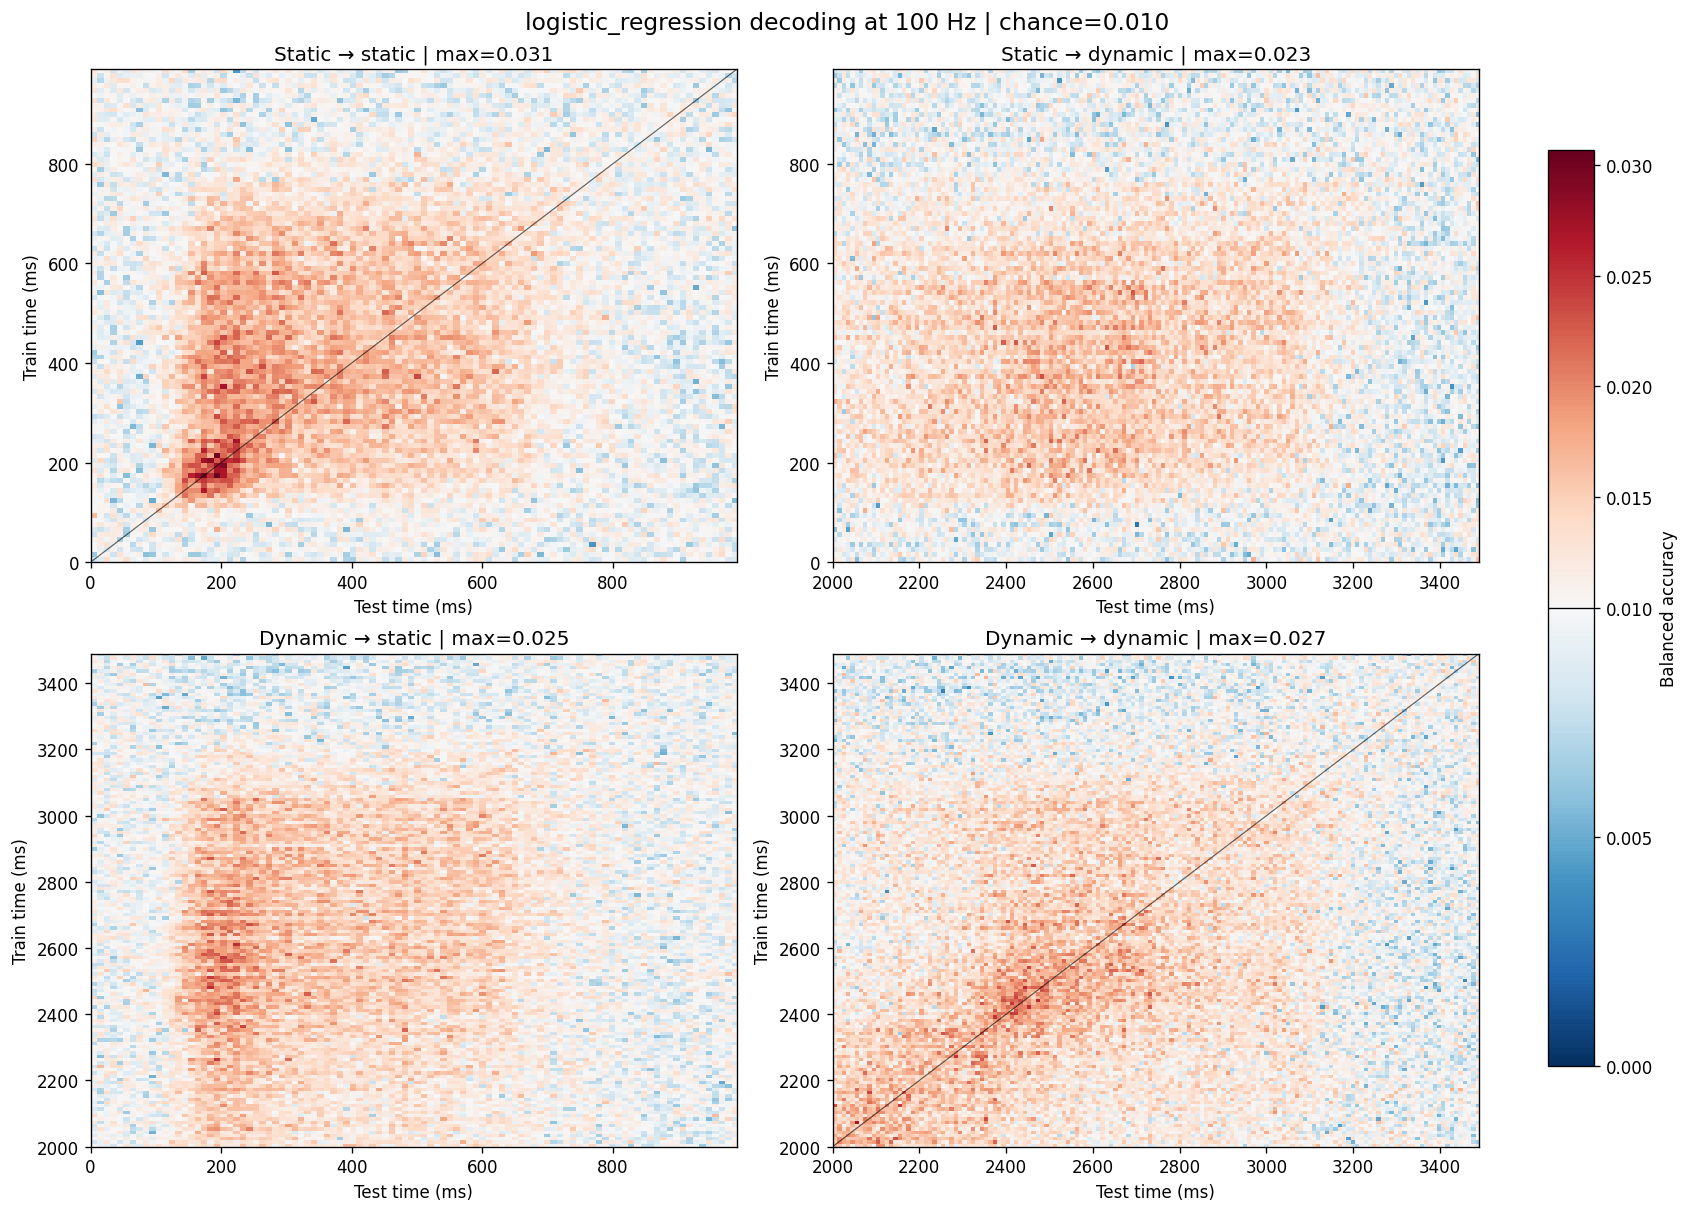

In [8]:
results = {
    "Static → static": (static_to_static, static_times_ms, static_times_ms),
    "Static → dynamic": (static_to_dynamic, static_times_ms, dynamic_times_ms),
    "Dynamic → static": (dynamic_to_static, dynamic_times_ms, static_times_ms),
    "Dynamic → dynamic": (dynamic_to_dynamic, dynamic_times_ms, dynamic_times_ms),
}
maximum_accuracy = max(np.nanmax(matrix) for matrix, _, _ in results.values())
color_limit = max(maximum_accuracy, chance_accuracy + 1e-6)
normalization = TwoSlopeNorm(vmin=0, vcenter=chance_accuracy, vmax=color_limit)

figure, axes = plt.subplots(2, 2, figsize=(14, 10), constrained_layout=True)
for axis, (title, (matrix, train_times, test_times)) in zip(axes.flat, results.items()):
    image = axis.imshow(
        matrix, origin="lower", aspect="auto", cmap="RdBu_r",
        norm=normalization, extent=[
            test_times[0], test_times[-1], train_times[0], train_times[-1],
        ],
    )
    axis.set(
        title=f"{title} | max={np.nanmax(matrix):.3f}",
        xlabel="Test time (ms)", ylabel="Train time (ms)",
    )
    if np.array_equal(train_times, test_times):
        axis.plot(test_times, train_times, color="black", linewidth=0.7, alpha=0.6)
    # end if within-condition matrix
# end for axis

colorbar = figure.colorbar(image, ax=axes, shrink=0.85, label="Balanced accuracy")
colorbar.ax.axhline(chance_accuracy, color="black", linewidth=0.8)
figure.suptitle(
    f"{cfg.classifier_name} decoding at {cfg.target_fs:g} Hz | chance={chance_accuracy:.3f}",
    fontsize=14,
)
plt.show()


In [9]:
# Preserve fold-level within-condition estimates for uncertainty analyses.
if cfg.save_results:
    results_dir = Path(
        cfg.results_dir
        or PROJECT_ROOT / "results" / "temporal_generalization_decoding"
        / f"{cfg.dynamic_exp_name}_vs_{cfg.static_exp_name}"
    )
    results_dir.mkdir(parents=True, exist_ok=True)
    result_path = results_dir / f"{cfg.classifier_name}_static_{cfg.static_response}_from_{cfg.dynamic_start_ms:g}ms_{cfg.target_fs:g}hz.npz"
    np.savez_compressed(
        result_path,
        static_to_static=static_to_static,
        dynamic_to_dynamic=dynamic_to_dynamic,
        static_to_dynamic=static_to_dynamic,
        dynamic_to_static=dynamic_to_static,
        static_fold_scores=static_fold_scores,
        dynamic_fold_scores=dynamic_fold_scores,
        static_fold_alphas=static_fold_alphas,
        dynamic_fold_alphas=dynamic_fold_alphas,
        static_to_dynamic_alphas=static_to_dynamic_alphas,
        dynamic_to_static_alphas=dynamic_to_static_alphas,
        static_times_ms=static_times_ms,
        dynamic_times_ms=dynamic_times_ms,
        static_labels=static_labels,
        dynamic_labels=dynamic_labels,
        shared_stimuli=np.asarray(shared_stimuli),
        channel_numbers=channel_numbers,
        chance_accuracy=chance_accuracy,
        classifier_name=cfg.classifier_name,
        alpha_values=np.asarray(cfg.alpha_values),
        alpha_cv_splits=cfg.alpha_cv_splits,
        n_splits=cfg.n_splits,
        target_fs=cfg.target_fs,
        static_response=cfg.static_response,
    )
    print(f"Saved: {result_path}")
# end if cfg.save_results


Saved: /Users/tizianocausin/Desktop/static_dynamic/results/temporal_generalization_decoding/baby1_260716to24_vs_baby1_260718to27/logistic_regression_static_last_frame_from_2000ms_100hz.npz
